# Exercícios de Aula — Otimização em Machine Learning

**FH Kufstein Tirol — Ian Calixto**  
*Baseado nos quadros da aula de Statistisches Lernen 2*

---

## O que esta aula cobre?

Os dois quadros mostram o **problema central de otimização** em ML:

> **Ziel (Objetivo):** Encontrar $\theta^*$ que minimiza $\ell(\theta)$

| Quadro | Tópico |
|--------|--------|
| **Quadro 1** | Função de perda + Gradient Descent + Momentum + Nesterov |
| **Quadro 2** | Loss com Minibatch (SGD) + Batch Size |

---

## Índice

1. A Função de Perda e o Objetivo
2. Gradient Descent — O Fundamento
3. Momentum — 1ª Melhoria
4. Nesterov Acceleration — 2ª Melhoria
5. SGD com Minibatch — Escalar para Grandes Datasets
6. Comparação Final dos Métodos

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


---

## 1. A Função de Perda e o Objetivo da Otimização

### Ziel (Objetivo) — do Quadro 1:

> *Finde $\theta^*$ so dass $\ell(\theta^*) \leq L(\theta)$ für alle anderen $\theta$*  
> → Encontre $\theta^*$ tal que $\ell(\theta^*) \leq \ell(\theta)$ para todos os outros $\theta$

### A Fórmula Geral:

$$\boxed{\ell(\theta) = \frac{1}{N} \sum_{i=1}^{N} D(f_\theta(x_i),\, y_i) + \lambda R(\theta)}$$

### O que cada parte significa?

| Símbolo | Significado | Papel |
|---------|-------------|-------|
| $\theta$ | Parâmetros do modelo (pesos) | O que o algoritmo aprende |
| $N$ | **Anzahl der Trainingsbeispiele** — número de exemplos | Tamanho do dataset |
| $D(f_\theta(x_i), y_i)$ | **Discrepância** previsão vs. valor real | Mede o erro por amostra |
| $\frac{1}{N}\sum$ | Média do erro | Erro médio de treino |
| $\lambda R(\theta)$ | Regularização (Ridge, Lasso…) | Penaliza modelos complexos |

### Por que é a base de TUDO?

- **Regressão Linear:** $D$ = MSE, $R$ = 0  
- **Ridge:** $D$ = MSE, $R(\theta) = \|\theta\|^2$  
- **Redes Neurais:** $D$ = cross-entropy, $R$ = weight decay  
- **Lasso:** $D$ = MSE, $R(\theta) = \|\theta\|_1$

O algoritmo de aprendizado é simplesmente **um método para encontrar $\theta^*$** — o mínimo de $\ell$.

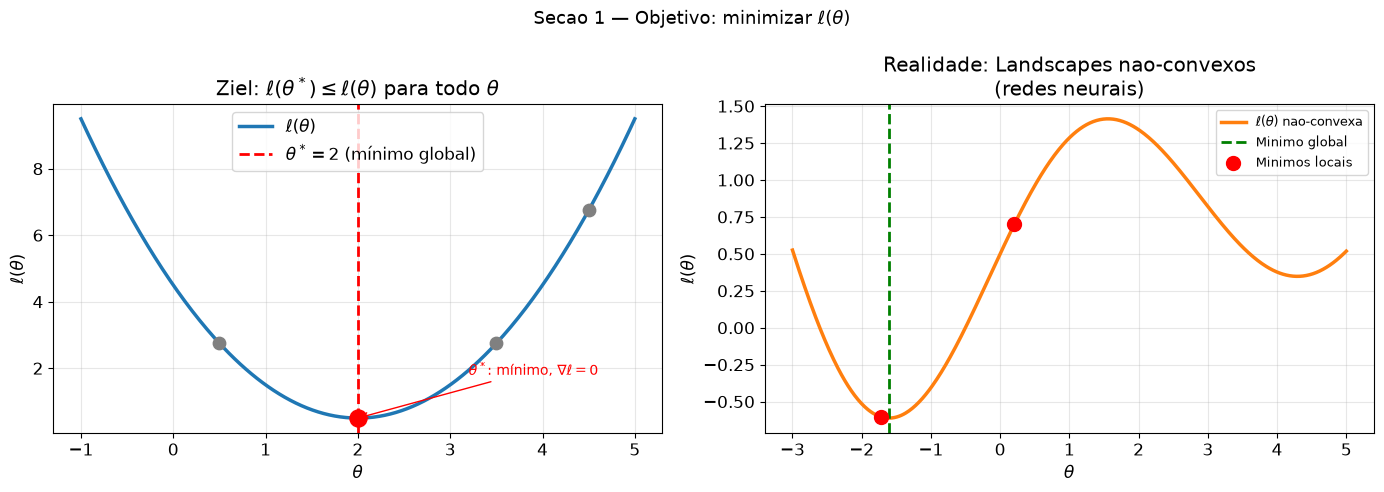

In [2]:
# Visualizando o objetivo: encontrar theta* que minimiza l(theta)
theta_v = np.linspace(-1, 5, 300)
loss_v  = (theta_v - 2)**2 + 0.5   # função de perda ilustrativa

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss convexa
ax = axes[0]
ax.plot(theta_v, loss_v, 'tab:blue', lw=2.5, label=r'$\ell(\theta)$')
ax.axvline(2.0, color='red', ls='--', lw=2, label=r'$\theta^* = 2$ (mínimo global)')
ax.scatter([2.0], [0.5], s=150, color='red', zorder=5)
ax.annotate(r'$\theta^*$: mínimo, $\nabla\ell=0$', xy=(2.0, 0.5), xytext=(3.2, 1.8),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)
for t_ex in [0.5, 3.5, 4.5]:
    ax.scatter([t_ex], [(t_ex-2)**2+0.5], s=80, color='gray', zorder=4)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\ell(\theta)$')
ax.set_title(r'Ziel: $\ell(\theta^*) \leq \ell(\theta)$ para todo $\theta$')
ax.legend()

# Gráfico 2: Loss não-convexa (redes neurais)
theta2 = np.linspace(-3, 5, 500)
loss2  = np.sin(theta2) * np.exp(-0.1*theta2) + 0.3*theta2**2 * 0.08 + 0.5
ax = axes[1]
ax.plot(theta2, loss2, 'tab:orange', lw=2.5, label=r'$\ell(\theta)$ nao-convexa')
ax.axvline(theta2[np.argmin(loss2)], color='green', ls='--', lw=2, label='Minimo global')
for idx in [80, 200]:
    lbl = 'Minimos locais' if idx == 80 else ''
    ax.scatter([theta2[idx]], [loss2[idx]], s=100, color='red', zorder=5, label=lbl)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\ell(\theta)$')
ax.set_title('Realidade: Landscapes nao-convexos\n(redes neurais)')
ax.legend(fontsize=9)

plt.suptitle('Secao 1 — Objetivo: minimizar $\\ell(\\theta)$', fontsize=13)
plt.tight_layout(); plt.show()

---

## 2. Gradient Descent — Grundlage für alle Optimierungsverfahren

### Ziel desta seção:
> Entender por que o GD é o **fundamento de todos os otimizadores** e como funciona passo a passo.

### A Fórmula — do Quadro 1:

$$\boxed{\theta_{t+1} = \theta_t - \eta_t \nabla \ell(\theta_t)}$$

onde $\eta_t$ é a **learning rate** (taxa de aprendizado).

### Por que subtrair o gradiente?

O gradiente $\nabla \ell(\theta_t)$ aponta na **direção de maior crescimento** de $\ell$.  
Para **minimizar**, movemos na direção **oposta**:

$$\theta_{t+1} = \theta_t - \eta_t \nabla\ell(\theta_t)$$

### Passo a passo:

```
1. Inicializar theta_0 aleatoriamente
2. Para t = 0, 1, 2, ...:
   a) Calcular: g = nabla(l(theta_t))   <- direção de subida
   b) Atualizar: theta_{t+1} = theta_t - eta_t * g  <- descer
   c) Parar quando ||g|| ≈ 0
3. Retornar theta_t como theta*
```

### Papel da Learning Rate $\eta_t$:

| $\eta_t$ | Efeito |
|-----------|--------|
| Muito grande | Passos enormes → divergência (overshooting) |
| Muito pequena | Passos minúsculos → convergência lenta |
| Ideal | Convergência suave para o mínimo |

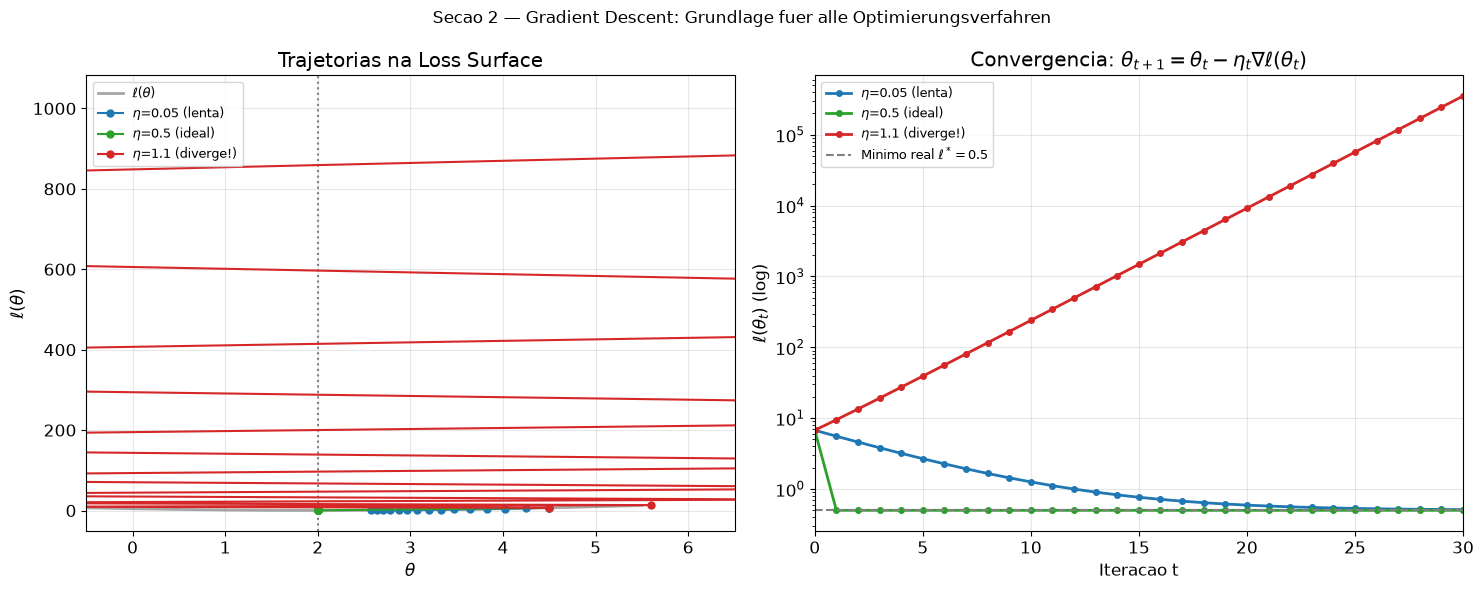

=== Passo a passo GD (eta=0.5) ===
  t |  theta_t |     grad |     loss
--------------------------------------
  0 |   4.5000 |   5.0000 |   6.7500
  1 |   2.0000 |   5.0000 |   0.5000
  2 |   2.0000 |   0.0000 |   0.5000
  3 |   2.0000 |   0.0000 |   0.5000
  4 |   2.0000 |   0.0000 |   0.5000
  5 |   2.0000 |   0.0000 |   0.5000
  6 |   2.0000 |   0.0000 |   0.5000
  7 |   2.0000 |   0.0000 |   0.5000
  8 |   2.0000 |   0.0000 |   0.5000
  9 |   2.0000 |   0.0000 |   0.5000
 10 |   2.0000 |   0.0000 |   0.5000


In [3]:
# Gradient Descent: comparar 3 learning rates
def loss_fn(t): return (t - 2)**2 + 0.5
def grad_fn(t): return 2*(t - 2)

def gradient_descent(t0, eta, n):
    thetas = [t0]; losses = [loss_fn(t0)]; grads = []
    t = t0
    for _ in range(n):
        g = grad_fn(t)
        t = t - eta * g
        thetas.append(t); losses.append(loss_fn(t)); grads.append(g)
    return thetas, losses, grads

t0 = 4.5; n_steps = 30
etas   = [0.05, 0.5, 1.1]
colors = ['tab:blue', 'tab:green', 'tab:red']
labels = [r'$\eta$=0.05 (lenta)', r'$\eta$=0.5 (ideal)', r'$\eta$=1.1 (diverge!)']

theta_plot = np.linspace(-0.5, 5.5, 300)
fig, axes  = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(theta_plot, loss_fn(theta_plot), 'k-', lw=2, alpha=0.35, label=r'$\ell(\theta)$')
ax.axvline(2.0, color='gray', ls=':', lw=1.5)
for eta, c, lbl in zip(etas, colors, labels):
    th, lo, _ = gradient_descent(t0, eta, n_steps)
    ax.plot(th[:15], [loss_fn(x) for x in th[:15]], 'o-', color=c, ms=5, lw=1.5, label=lbl)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel(r'$\ell(\theta)$')
ax.set_title('Trajetorias na Loss Surface'); ax.legend(fontsize=9); ax.set_xlim(-0.5, 6.5)

ax = axes[1]
for eta, c, lbl in zip(etas, colors, labels):
    _, lo, _ = gradient_descent(t0, eta, n_steps)
    ax.semilogy(lo, 'o-', color=c, ms=4, lw=2, label=lbl)
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label=r'Minimo real $\ell^*=0.5$')
ax.set_xlabel('Iteracao t'); ax.set_ylabel(r'$\ell(\theta_t)$ (log)')
ax.set_title(r'Convergencia: $\theta_{t+1} = \theta_t - \eta_t \nabla\ell(\theta_t)$')
ax.legend(fontsize=9); ax.set_xlim(0, n_steps)

plt.suptitle('Secao 2 — Gradient Descent: Grundlage fuer alle Optimierungsverfahren', fontsize=12)
plt.tight_layout(); plt.show()

# Passos numericos
print('=== Passo a passo GD (eta=0.5) ===')
print(f'{"t":>3} | {"theta_t":>8} | {"grad":>8} | {"loss":>8}')
print('-'*38)
th, lo, gr = gradient_descent(t0, 0.5, 10)
for i in range(11):
    g = gr[i-1] if i > 0 else grad_fn(t0)
    print(f'{i:>3} | {th[i]:>8.4f} | {g:>8.4f} | {lo[i]:>8.4f}')

---

## 3. Momentum — 1ª Verbesserung (Melhoria)

### Ziel desta seção:
> Entender por que o GD puro é **lento em vales estreitos** e como o Momentum acumula velocidade para resolver isso.

### A Fórmula — do Quadro 1:

$$\boxed{v_{t+1} = \beta\, v_t + \nabla\ell(\theta_t), \qquad \theta_{t+1} = \theta_t - \eta_t\, v_{t+1}}$$

| Símbolo | Significado |
|---------|-------------|
| $v_t$ | **Velocity** — média ponderada exponencial dos gradientes passados |
| $\beta$ | Coeficiente de momentum ($\approx 0.9$) |
| $\nabla\ell(\theta_t)$ | Gradiente atual |

### Por que funciona?

Expandindo a recursão:
$$v_{t+1} = \nabla\ell(\theta_t) + \beta\nabla\ell(\theta_{t-1}) + \beta^2\nabla\ell(\theta_{t-2}) + \ldots$$

→ É uma **EMA (média exponencial ponderada)** dos gradientes.

**Efeito prático:**
- Direções **consistentes** (mesmo sentido) → velocidade acumula → passos maiores
- Direções **oscilantes** (sinal alternado) → gradientes se cancelam → amortecimento

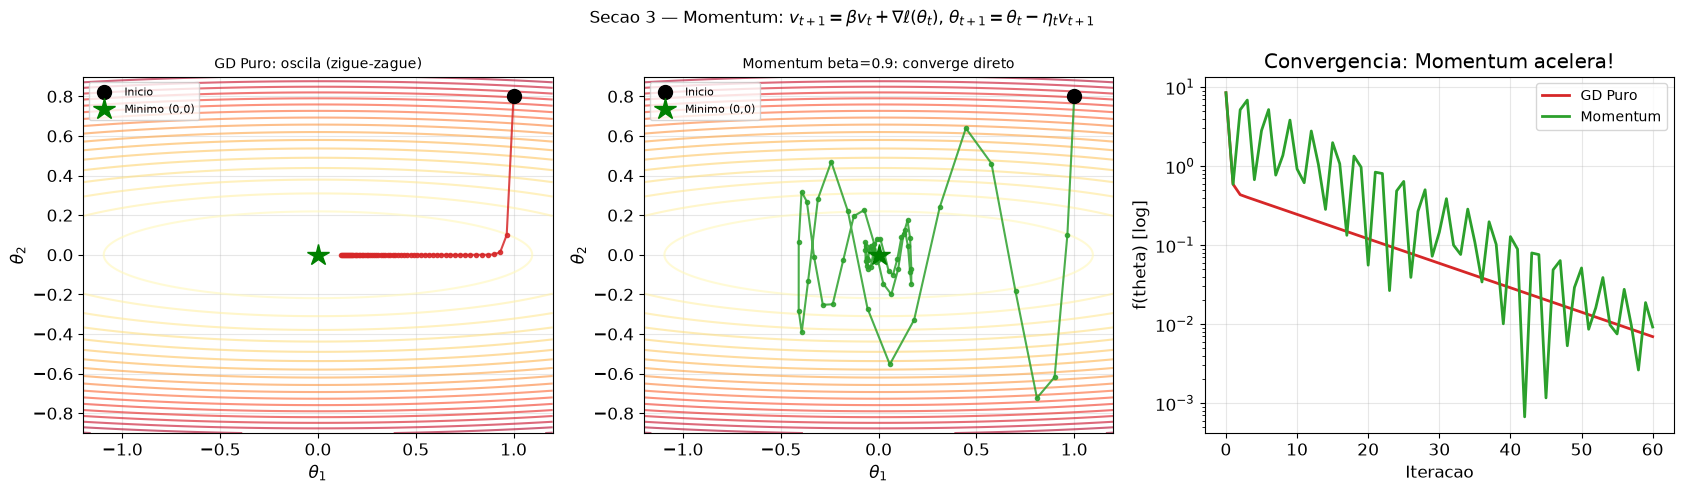

=== Efeito da EMA nos gradientes (beta=0.9) ===
  0 passos atras: peso = 1.0000  ████████████████████
  1 passos atras: peso = 0.9000  ██████████████████
  2 passos atras: peso = 0.8100  ████████████████
  3 passos atras: peso = 0.7290  ██████████████
  4 passos atras: peso = 0.6561  █████████████
  5 passos atras: peso = 0.5905  ███████████
  6 passos atras: peso = 0.5314  ██████████
  7 passos atras: peso = 0.4783  █████████


In [4]:
# GD puro vs. GD + Momentum em vale anisotrópico
# f(θ1, θ2) = 0.5*θ1² + 12.5*θ2²
def f2d(p):    return 0.5*p[0]**2 + 12.5*p[1]**2
def g2d(p):    return np.array([p[0], 25*p[1]])

def gd2d(p0, eta, n):
    path = [p0.copy()]; p = p0.copy()
    for _ in range(n):
        p = p - eta*g2d(p)
        path.append(p.copy())
    return np.array(path)

def mom2d(p0, eta, beta, n):
    path = [p0.copy()]; p = p0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta*v + g2d(p)    # acumular velocidade
        p = p - eta*v          # atualizar posição
        path.append(p.copy())
    return np.array(path)

p0 = np.array([1.0, 0.8]); n = 60
path_gd  = gd2d(p0, 0.035, n)
path_mom = mom2d(p0, 0.035, 0.9, n)

T1, T2 = np.meshgrid(np.linspace(-1.2,1.2,200), np.linspace(-0.9,0.9,200))
Z = 0.5*T1**2 + 12.5*T2**2

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, path, title, color in zip(
    axes[:2],
    [path_gd, path_mom],
    ['GD Puro: oscila (zigue-zague)', 'Momentum beta=0.9: converge direto'],
    ['tab:red', 'tab:green']
):
    ax.contour(T1, T2, Z, levels=20, cmap='YlOrRd', alpha=0.6)
    ax.plot(path[:,0], path[:,1], 'o-', color=color, ms=3, lw=1.5, alpha=0.85)
    ax.plot(*p0, 'ko', ms=10, zorder=6, label='Inicio')
    ax.plot(0, 0, 'g*', ms=16, zorder=6, label='Minimo (0,0)')
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
    ax.set_xlabel(r'$\theta_1$'); ax.set_ylabel(r'$\theta_2$')

ax = axes[2]
ax.semilogy([f2d(p) for p in path_gd],  'tab:red',   lw=2, label='GD Puro')
ax.semilogy([f2d(p) for p in path_mom], 'tab:green', lw=2, label='Momentum')
ax.set_xlabel('Iteracao'); ax.set_ylabel('f(theta) [log]')
ax.set_title('Convergencia: Momentum acelera!'); ax.legend(fontsize=10)

plt.suptitle(r'Secao 3 — Momentum: $v_{t+1}=\beta v_t+\nabla\ell(\theta_t)$, $\theta_{t+1}=\theta_t-\eta_t v_{t+1}$', fontsize=12)
plt.tight_layout(); plt.show()

print('=== Efeito da EMA nos gradientes (beta=0.9) ===')
for k in range(8):
    barra = chr(9608)*int(0.9**k * 20)
    print(f'  {k} passos atras: peso = {0.9**k:.4f}  {barra}')

---

## 4. Nesterov Acceleration — 2ª Verbesserung (Melhoria)

### Ziel desta seção:
> Entender como o Nesterov melhora o Momentum com um **look-ahead**: calcular o gradiente onde vamos chegar, não onde estamos.

### A Fórmula — do Quadro 1:

$$\boxed{v_{t+1} = \beta\, v_t + \nabla\ell(\theta_t - \eta\beta v_t), \qquad \theta_{t+1} = \theta_t - \eta\, v_{t+1}}$$

### A diferença crucial:

| Método | Onde calcula o gradiente? |
|--------|---------------------------|
| **Momentum** | Na posição **atual** $\theta_t$ |
| **Nesterov** | Na posição **projetada** $\theta_t - \eta\beta v_t$ (onde chegará) |

### Por que é melhor?

```
Momentum:  olha para onde ESTÁ, depois move
Nesterov:  olha para onde VAI CHEGAR, depois corrige
```

O Nesterov *freia* antes de ultrapassar o mínimo → menos oscilação, convergência mais rápida.

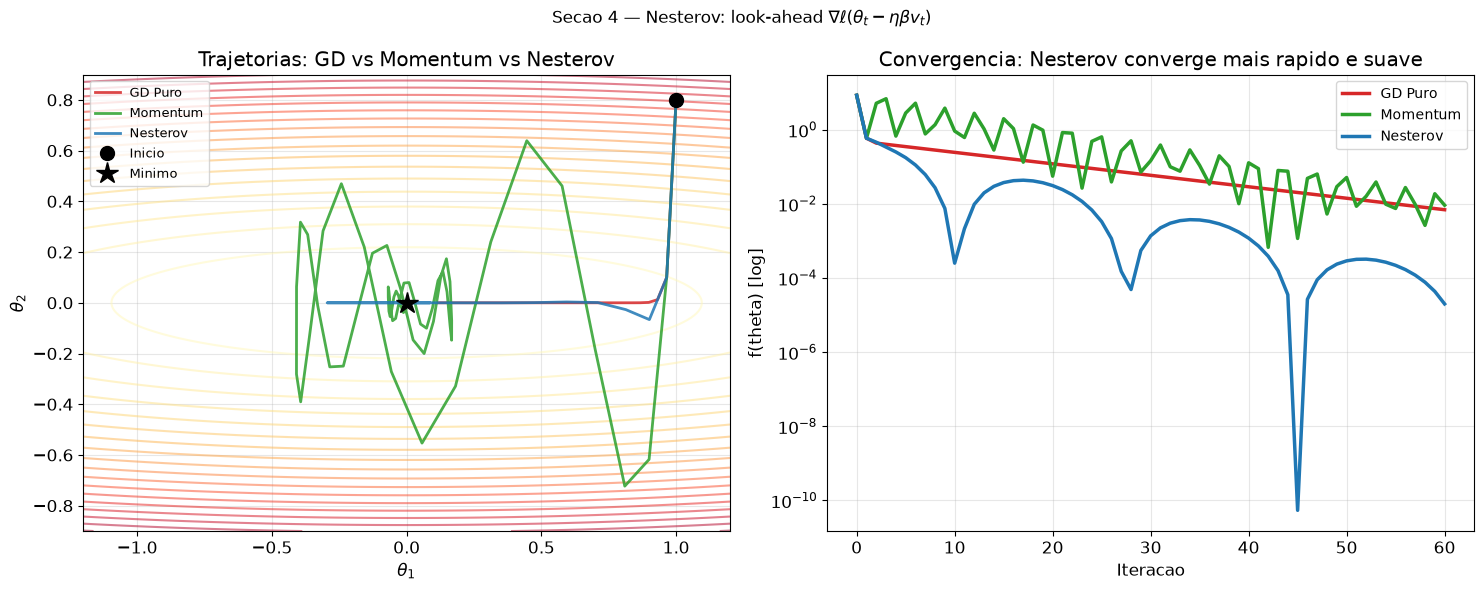

Resultados apos 60 iteracoes:
          GD: f = 0.00695421
    Momentum: f = 0.00920871
    Nesterov: f = 0.00001998


In [5]:
# GD vs. Momentum vs. Nesterov
def nes2d(p0, eta, beta, n):
    path = [p0.copy()]; p = p0.copy(); v = np.zeros(2)
    for _ in range(n):
        p_look = p - eta*beta*v          # posicao projetada (look-ahead)
        v = beta*v + g2d(p_look)         # gradiente NA posicao projetada
        p = p - eta*v
        path.append(p.copy())
    return np.array(path)

path_nes = nes2d(p0, 0.035, 0.9, n)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.contour(T1, T2, Z, levels=20, cmap='YlOrRd', alpha=0.5)
for path, lbl, c in [
    (path_gd,  'GD Puro',  'tab:red'),
    (path_mom, 'Momentum', 'tab:green'),
    (path_nes, 'Nesterov', 'tab:blue'),
]:
    ax.plot(path[:,0], path[:,1], '-', color=c, lw=2, label=lbl, alpha=0.85)
ax.plot(*p0, 'ko', ms=10, zorder=6, label='Inicio')
ax.plot(0, 0, 'k*', ms=16, zorder=6, label='Minimo')
ax.set_title('Trajetorias: GD vs Momentum vs Nesterov')
ax.legend(fontsize=9); ax.set_xlabel(r'$\theta_1$'); ax.set_ylabel(r'$\theta_2$')

ax = axes[1]
for path, lbl, c in [
    (path_gd,  'GD Puro',  'tab:red'),
    (path_mom, 'Momentum', 'tab:green'),
    (path_nes, 'Nesterov', 'tab:blue'),
]:
    ax.semilogy([f2d(p) for p in path], color=c, lw=2.5, label=lbl)
ax.set_xlabel('Iteracao'); ax.set_ylabel('f(theta) [log]')
ax.set_title('Convergencia: Nesterov converge mais rapido e suave')
ax.legend(fontsize=10)

plt.suptitle(r'Secao 4 — Nesterov: look-ahead $\nabla\ell(\theta_t - \eta\beta v_t)$', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Resultados apos {n} iteracoes:')
for path, lbl in [(path_gd,'GD'),(path_mom,'Momentum'),(path_nes,'Nesterov')]:
    print(f'  {lbl:>10}: f = {f2d(path[-1]):.8f}')

---

## 5. SGD com Minibatch — Escalar para Grandes Datasets

### Ziel desta seção:
> Entender por que o GD batch é inviável para datasets grandes e como o SGD resolve isso.

### O Problema do Batch GD

A fórmula original processa **todos os N exemplos** a cada passo — caro para $N = 10^6$!

### A Solução: Loss de Minibatch — do Quadro 2:

$$\boxed{\ell_B(\theta) = \frac{1}{|B|} \sum_{i=1}^{|B|} D(f_\theta(x_i),\, y_i) + \lambda R(\theta)}$$

### Terminologia do Quadro 2:

| Símbolo/Termo | Significado |
|---------------|-------------|
| $B$ | **Teilmenge** — subconjunto dos dados de treino amostrado aleatoriamente |
| $|B|$ | **Batch size** — tamanho do subconjunto (ex: 32, 64, 128, 256) |
| Mini-batch | *Die Teilmengen B werden batch genannt und in Trainingsiteration zufällig gewählt* |
| SGD | **Stochastic** GD — o gradiente é estimado (ruidoso) |

### Casos Especiais:

| Variante | $|B|$ | Alias |
|----------|-------|-------|
| Batch GD | $N$ (todos) | GD clássico |
| Mini-batch SGD | 32–512 | *SGD* na prática |
| Online SGD | 1 | SGD original |

### Propriedade Fundamental:

$$\mathbb{E}_B[\nabla\ell_B(\theta)] = \nabla\ell(\theta)$$

O gradiente do minibatch é, **em média**, igual ao gradiente completo.

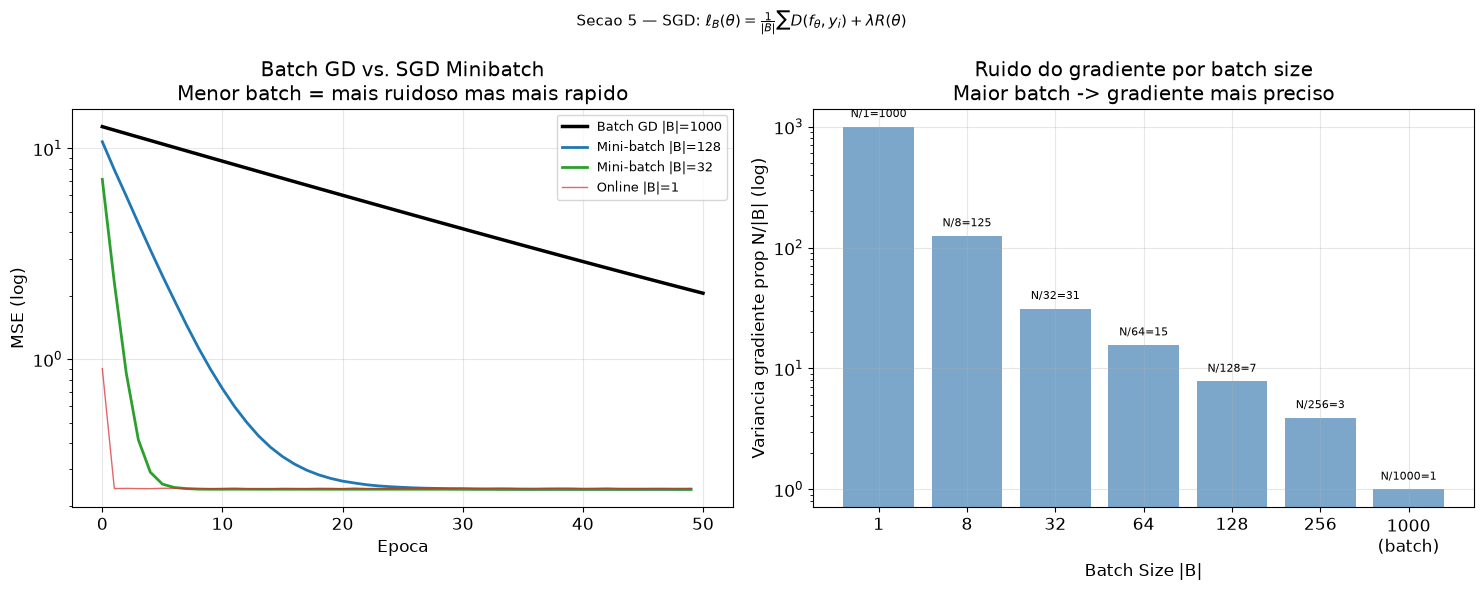

In [6]:
# SGD Minibatch vs. Batch GD
np.random.seed(42)
N = 1000
X_d = np.random.randn(N, 2)
y_d = X_d @ np.array([3.0, -2.0]) + 0.5*np.random.randn(N)

def mse(theta, X, y):  return np.mean((X@theta - y)**2)
def grd(theta, X, y):  return 2*X.T@(X@theta - y)/len(y)

def batch_gd_fn(t0, eta, n_ep, X, y):
    t = t0.copy(); losses = [mse(t,X,y)]
    for _ in range(n_ep):
        t -= eta*grd(t,X,y)
        losses.append(mse(t,X,y))
    return losses

def sgd_mb(t0, eta, n_ep, X, y, bs=32):
    t = t0.copy(); losses = []
    for _ in range(n_ep):
        idx = np.random.permutation(len(y))
        X_s, y_s = X[idx], y[idx]
        ep = []
        for s in range(0, len(y), bs):
            t -= eta*grd(t, X_s[s:s+bs], y_s[s:s+bs])
            ep.append(mse(t,X,y))
        losses.append(np.mean(ep))
    return losses

t0 = np.zeros(2); n_ep = 50
l_batch = batch_gd_fn(t0, 0.01, n_ep, X_d, y_d)
l_32    = sgd_mb(t0, 0.01, n_ep, X_d, y_d, bs=32)
l_128   = sgd_mb(t0, 0.01, n_ep, X_d, y_d, bs=128)
l_1     = sgd_mb(t0, 0.005, n_ep, X_d, y_d, bs=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
ax.semilogy(l_batch, 'k-',        lw=2.5, label=f'Batch GD |B|={N}')
ax.semilogy(l_128,   'tab:blue',  lw=2,   label='Mini-batch |B|=128')
ax.semilogy(l_32,    'tab:green', lw=2,   label='Mini-batch |B|=32')
ax.semilogy(l_1,     'tab:red',   lw=1,   label='Online |B|=1', alpha=0.7)
ax.set_xlabel('Epoca'); ax.set_ylabel('MSE (log)')
ax.set_title('Batch GD vs. SGD Minibatch\nMenor batch = mais ruidoso mas mais rapido')
ax.legend(fontsize=9)

ax = axes[1]
batch_sizes = [1, 8, 32, 64, 128, 256, N]
tick_lbl    = ['1', '8', '32', '64', '128', '256', str(N)+'\n(batch)']
bars = ax.bar(range(len(batch_sizes)), [N/b for b in batch_sizes], color='steelblue', alpha=0.7)
ax.set_xticks(range(len(batch_sizes))); ax.set_xticklabels(tick_lbl)
ax.set_xlabel('Batch Size |B|'); ax.set_ylabel('Variancia gradiente prop N/|B| (log)')
ax.set_yscale('log')
ax.set_title('Ruido do gradiente por batch size\nMaior batch -> gradiente mais preciso')
for bar, bs in zip(bars, batch_sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.2,
            f'N/{bs}={N//bs}', ha='center', fontsize=8)

plt.suptitle(r'Secao 5 — SGD: $\ell_B(\theta)=\frac{1}{|B|}\sum D(f_{\theta},y_i)+\lambda R(\theta)$', fontsize=11)
plt.tight_layout(); plt.show()

---

## 6. Comparação Final — Todos os Métodos

### Ziel desta seção:
> Consolidar os métodos e saber **qual escolher** em cada situação.

### Hierarquia dos Métodos (dos dois quadros):

```
OBJETIVO: minimizar l(theta)
│
└── Gradient Descent — Grundlage (Fundamento)
    │   theta_{t+1} = theta_t - eta_t * nabla(l(theta_t))
    │
    ├── Verbesserungen (Melhorias):
    │   ├── Momentum:  v_{t+1} = beta*v_t + nabla(l(theta_t))
    │   └── Nesterov:  v_{t+1} = beta*v_t + nabla(l(theta_t - eta*beta*v_t))
    │
    └── Minibatch SGD (Quadro 2):
            theta_{t+1} = theta_t - eta_t * nabla(l_B(theta_t))
```

### Tabela de Decisão:

| Situação | Método Recomendado |
|----------|-------------------|
| Dataset pequeno, problema convexo | Batch GD ou L-BFGS |
| Dataset grande, rede neural | SGD Minibatch + Momentum |
| Default seguro para deep learning | **Adam** ($\beta_1=0.9$, $\beta_2=0.999$) |

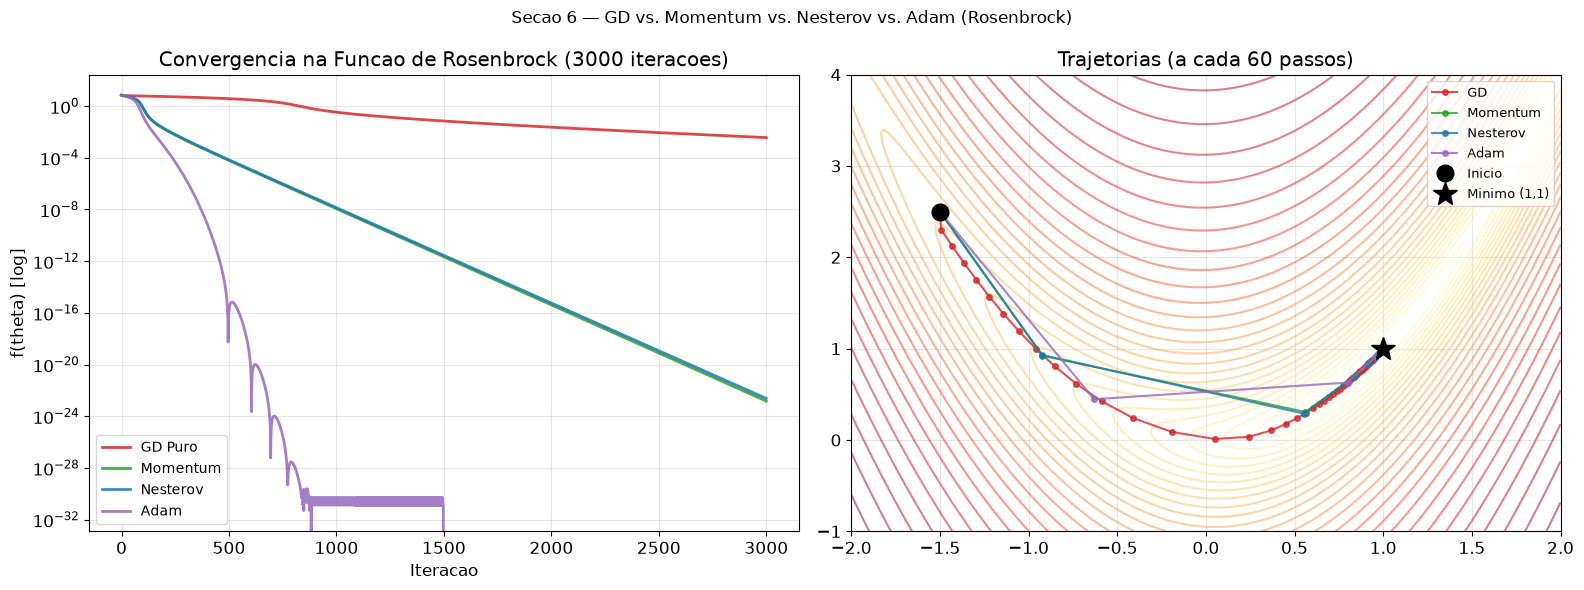

=== Resultado final (minimo verdadeiro: theta*=[1,1], f*=0) ===
          GD: f=0.003658  theta=[0.94003858 0.88117415]
    Momentum: f=0.000000  theta=[1. 1.]
    Nesterov: f=0.000000  theta=[1. 1.]
        Adam: f=0.000000  theta=[1. 1.]


In [7]:
# Comparação na Função de Rosenbrock (benchmark nao-convexo)
def f_ros(p):  return (1-p[0])**2 + 10*(p[1]-p[0]**2)**2
def g_ros(p):  return np.array([-2*(1-p[0])-40*p[0]*(p[1]-p[0]**2), 20*(p[1]-p[0]**2)])

def gd_ros(p0, eta, n):
    path=[p0.copy()]; p=p0.copy()
    for _ in range(n): p-=eta*g_ros(p); path.append(p.copy())
    return np.array(path)

def mom_ros(p0, eta, beta, n):
    path=[p0.copy()]; p=p0.copy(); v=np.zeros(2)
    for _ in range(n): v=beta*v+g_ros(p); p-=eta*v; path.append(p.copy())
    return np.array(path)

def nes_ros(p0, eta, beta, n):
    path=[p0.copy()]; p=p0.copy(); v=np.zeros(2)
    for _ in range(n): v=beta*v+g_ros(p-eta*beta*v); p-=eta*v; path.append(p.copy())
    return np.array(path)

def adam_ros(p0, alpha=0.05, b1=0.9, b2=0.999, eps=1e-8, n=3000):
    path=[p0.copy()]; p=p0.copy(); m=np.zeros(2); v=np.zeros(2)
    for t in range(1, n+1):
        g=g_ros(p); m=b1*m+(1-b1)*g; v=b2*v+(1-b2)*g**2
        p=p-alpha*(m/(1-b1**t))/(np.sqrt(v/(1-b2**t))+eps)
        path.append(p.copy())
    return np.array(path)

p0_ros = np.array([-1.5, 2.5]); n_ros = 3000
pg = gd_ros(p0_ros, 0.002, n_ros)
pm = mom_ros(p0_ros, 0.002, 0.9, n_ros)
pn = nes_ros(p0_ros, 0.002, 0.9, n_ros)
pa = adam_ros(p0_ros, n=n_ros)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for path, lbl, c in [
    (pg,'GD Puro','tab:red'), (pm,'Momentum','tab:green'),
    (pn,'Nesterov','tab:blue'), (pa,'Adam','tab:purple')
]:
    ax.semilogy([f_ros(p) for p in path], color=c, lw=2, alpha=0.85, label=lbl)
ax.set_xlabel('Iteracao'); ax.set_ylabel('f(theta) [log]')
ax.set_title(f'Convergencia na Funcao de Rosenbrock ({n_ros} iteracoes)')
ax.legend(fontsize=10)

ax = axes[1]
xg = np.linspace(-2,2,200); yg = np.linspace(-1,4,200)
Xg,Yg = np.meshgrid(xg,yg)
ax.contour(Xg, Yg, np.log((1-Xg)**2+10*(Yg-Xg**2)**2+1), levels=30, cmap='YlOrRd', alpha=0.5)
step=60
for path, lbl, c in [
    (pg,'GD','tab:red'), (pm,'Momentum','tab:green'),
    (pn,'Nesterov','tab:blue'), (pa,'Adam','tab:purple')
]:
    ax.plot(path[::step,0], path[::step,1], 'o-', color=c, ms=4, lw=1.5, label=lbl, alpha=0.8)
ax.plot(*p0_ros, 'ko', ms=12, zorder=8, label='Inicio')
ax.plot(1, 1, 'k*', ms=18, zorder=8, label='Minimo (1,1)')
ax.set_xlim(-2,2); ax.set_ylim(-1,4)
ax.set_title('Trajetorias (a cada 60 passos)'); ax.legend(fontsize=9)

plt.suptitle('Secao 6 — GD vs. Momentum vs. Nesterov vs. Adam (Rosenbrock)', fontsize=12)
plt.tight_layout(); plt.show()

print('=== Resultado final (minimo verdadeiro: theta*=[1,1], f*=0) ===')
for path, lbl in [(pg,'GD'),(pm,'Momentum'),(pn,'Nesterov'),(pa,'Adam')]:
    print(f'  {lbl:>10}: f={f_ros(path[-1]):.6f}  theta={path[-1]}')

---

## Resumo — O que a aula ensinou

### Quadro 1 — Fundamentos:

| Conceito | Fórmula | Ziel |
|----------|---------|------|
| **Função de Perda** | $\ell(\theta) = \frac{1}{N}\sum D(f_\theta(x_i),y_i) + \lambda R(\theta)$ | Medir erro médio + controlar complexidade |
| **Objetivo** | $\theta^* = \arg\min_\theta \ell(\theta)$ | Encontrar os melhores parâmetros |
| **GD** | $\theta_{t+1} = \theta_t - \eta_t \nabla\ell(\theta_t)$ | Fundamento de todos os otimizadores |
| **Momentum** | $v_{t+1} = \beta v_t + \nabla\ell(\theta_t)$ | EMA dos gradientes, reduz oscilações |
| **Nesterov** | $v_{t+1} = \beta v_t + \nabla\ell(\theta_t - \eta\beta v_t)$ | Look-ahead, mais rápido |

### Quadro 2 — Minibatch:

| Conceito | Fórmula | Ziel |
|----------|---------|------|
| **Loss Minibatch** | $\ell_B(\theta) = \frac{1}{|B|}\sum_{i=1}^{|B|} D(f_\theta(x_i),y_i) + \lambda R(\theta)$ | Escalar para datasets grandes |
| **SGD** | $\theta_{t+1} = \theta_t - \eta_t \nabla\ell_B(\theta_t)$ | Gradiente estimado por mini-batch |
| **Batch size** | $|B|$ | Trade-off: ruído vs. velocidade |

### Regra Prática:
- **Dataset pequeno:** Batch GD
- **Dataset grande:** SGD + Momentum
- **Default deep learning:** **Adam** (combina Momentum + escala adaptativa)